# Ячейка 1: Импорты, Фиксация Seed и Создание папок

In [4]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.ops import box_iou

homeworkDir = "."
artifacts = os.path.join(homeworkDir, "artifacts")
figures = os.path.join(artifacts, "figures")

os.makedirs(figures, exist_ok=True)
print(f"Папки созданы: {figures}")


# Фиксируем Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

# Выбираем устройство (GPU или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Создадим пустой список для записи всех результатов экспериментов (он пойдет в runs.csv)
results_log = []

Папки созданы: .\artifacts\figures
Используемое устройство: cuda


# Ячейка 2: Часть A - Данные (STL10) и Аугментации

Скачиваем датасет STL10...
Files already downloaded and verified
Files already downloaded and verified
Датасет загружен
Данные разделены: Train=4000, Val=1000, Test=8000


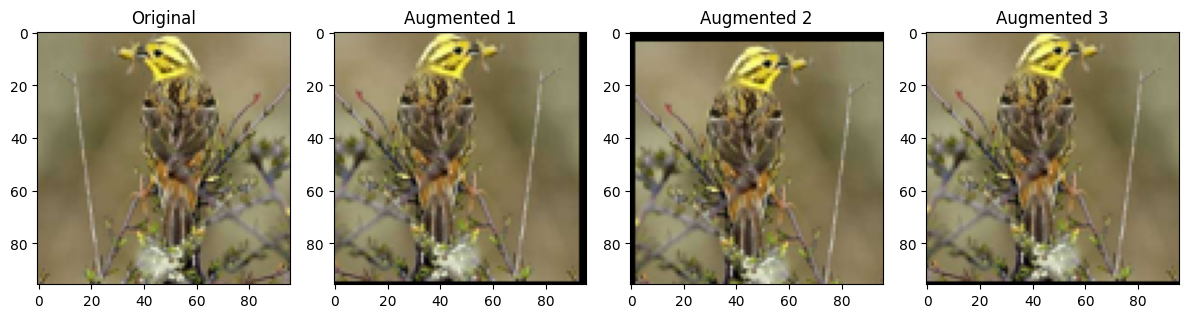

Аугментации визуализированы и сохранены!


In [5]:
# Трансформация для изображений
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Для ResNet18 (нужен размер 224x224 и нормализация)
resnet_weights = models.ResNet18_Weights.DEFAULT
transform_resnet_base = resnet_weights.transforms()
transform_resnet_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transform_resnet_base
])

print("Скачиваем датасет STL10...")
raw_train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=None)
raw_test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=None)
print("Датасет загружен")


# Класс для применения нужной трансформации к подмножеству
class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label


# Разбиваем Train (5000) на Train (4000) и Val (1000)
indices = list(range(len(raw_train_dataset)))
np.random.shuffle(indices)
train_idx, val_idx = indices[:4000], indices[4000:]

print(f"Данные разделены: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(raw_test_dataset)}")

# Визуализируем аугментацию
sample_img, _ = raw_train_dataset[0]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample_img)
axes[0].set_title("Original")

# Применим аугментацию
vis_aug = transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.RandomCrop(96, padding=4)])
for i in range(1, 4):
    axes[i].imshow(vis_aug(sample_img))
    axes[i].set_title(f"Augmented {i}")

plt.tight_layout()
plt.savefig(os.path.join(figures, "augmentations_preview.png"))
plt.show()
print("Аугментации визуализированы и сохранены!")

# Ячейка 3: Часть A - Архитектуры моделей и функции обучения

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 96x96 -> 48x48

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 48x48 -> 24x24
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 24 * 24, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Функция настройки ResNet (Transfer Learning)
def get_resnet_model(mode='head_only', num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if mode == 'head_only':
        # Замораживаем всю сеть
        for param in model.parameters():
            param.requires_grad = False
    elif mode == 'finetune':
        # Замораживаем ранние слои, оставляем обучаться только layer4 и полносвязный слой (fc)
        for name, param in model.named_parameters():
            if not name.startswith('layer4') and not name.startswith('fc'):
                param.requires_grad = False

    # Заменяем последний слой под наши 10 классов
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# Базовые функции обучения
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += labels.size(0)

    return running_loss / total, correct / total

# Ячейка 4: Часть A - Выполнение Экспериментов (C1-C4)


Запуск эксперимента C1: simple-cnn-base
Epoch 1/10 - Loss: 2.197 / 2.020 | Acc: 0.199 / 0.255
Epoch 2/10 - Loss: 1.796 / 1.786 | Acc: 0.347 / 0.347
Epoch 3/10 - Loss: 1.557 / 1.623 | Acc: 0.429 / 0.410
Epoch 4/10 - Loss: 1.407 / 1.574 | Acc: 0.491 / 0.424
Epoch 5/10 - Loss: 1.301 / 1.510 | Acc: 0.532 / 0.438
Epoch 6/10 - Loss: 1.203 / 1.496 | Acc: 0.577 / 0.450
Epoch 7/10 - Loss: 1.127 / 1.505 | Acc: 0.607 / 0.443
Epoch 8/10 - Loss: 1.050 / 1.476 | Acc: 0.636 / 0.454
Epoch 9/10 - Loss: 0.959 / 1.451 | Acc: 0.676 / 0.476
Epoch 10/10 - Loss: 0.877 / 1.455 | Acc: 0.707 / 0.486

Запуск эксперимента C2: simple-cnn-aug
Epoch 1/10 - Loss: 2.244 / 2.113 | Acc: 0.185 / 0.218
Epoch 2/10 - Loss: 1.985 / 1.883 | Acc: 0.280 / 0.310
Epoch 3/10 - Loss: 1.772 / 1.752 | Acc: 0.361 / 0.335
Epoch 4/10 - Loss: 1.634 / 1.724 | Acc: 0.408 / 0.377
Epoch 5/10 - Loss: 1.547 / 1.591 | Acc: 0.443 / 0.422
Epoch 6/10 - Loss: 1.478 / 1.518 | Acc: 0.472 / 0.451
Epoch 7/10 - Loss: 1.414 / 1.480 | Acc: 0.482 / 0.477


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Artem/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


Epoch 1/10 - Loss: 2.268 / 1.775 | Acc: 0.179 / 0.504
Epoch 2/10 - Loss: 1.509 / 1.173 | Acc: 0.642 / 0.822
Epoch 3/10 - Loss: 1.007 / 0.807 | Acc: 0.848 / 0.888
Epoch 4/10 - Loss: 0.713 / 0.589 | Acc: 0.894 / 0.916
Epoch 5/10 - Loss: 0.552 / 0.471 | Acc: 0.911 / 0.926
Epoch 6/10 - Loss: 0.455 / 0.403 | Acc: 0.916 / 0.934
Epoch 7/10 - Loss: 0.399 / 0.355 | Acc: 0.925 / 0.940
Epoch 8/10 - Loss: 0.357 / 0.324 | Acc: 0.930 / 0.939
Epoch 9/10 - Loss: 0.325 / 0.302 | Acc: 0.935 / 0.938
Epoch 10/10 - Loss: 0.304 / 0.282 | Acc: 0.930 / 0.940

Запуск эксперимента C4: resnet-finetune
Epoch 1/10 - Loss: 1.543 / 0.731 | Acc: 0.535 / 0.815
Epoch 2/10 - Loss: 0.572 / 0.380 | Acc: 0.895 / 0.890
Epoch 3/10 - Loss: 0.317 / 0.261 | Acc: 0.932 / 0.932
Epoch 4/10 - Loss: 0.218 / 0.224 | Acc: 0.953 / 0.937
Epoch 5/10 - Loss: 0.156 / 0.202 | Acc: 0.969 / 0.945
Epoch 6/10 - Loss: 0.115 / 0.189 | Acc: 0.982 / 0.953
Epoch 7/10 - Loss: 0.087 / 0.180 | Acc: 0.989 / 0.955
Epoch 8/10 - Loss: 0.066 / 0.173 | Acc: 

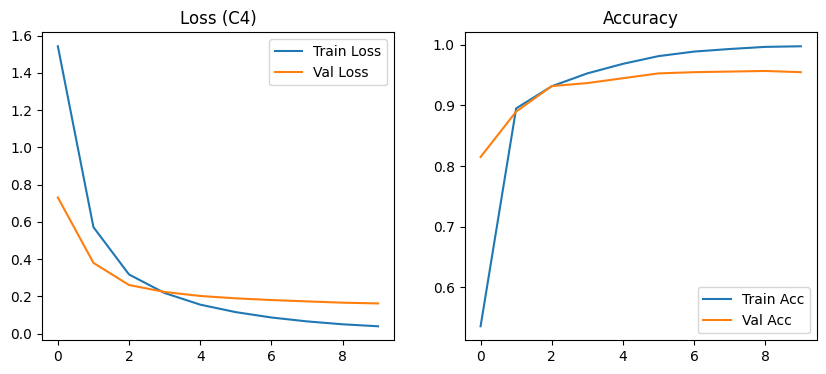

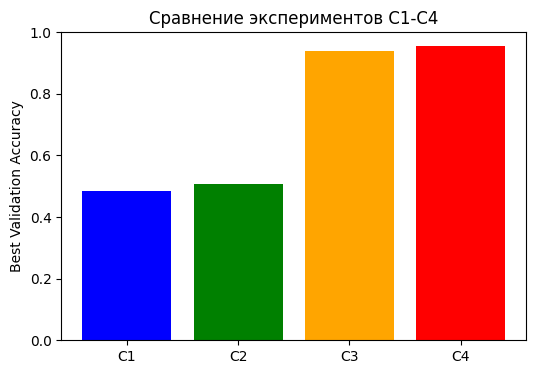

Артефакты Части A сохранены!


In [9]:
EPOCHS = 10
BATCH_SIZE = 512

experiments =[
    {"id": "C1", "name": "simple-cnn-base", "model_fn": lambda: SimpleCNN(), "t_train": transform_base, "t_val": transform_base, "lr": 1e-3},
    {"id": "C2", "name": "simple-cnn-aug",  "model_fn": lambda: SimpleCNN(), "t_train": transform_aug, "t_val": transform_base, "lr": 1e-3},
    {"id": "C3", "name": "resnet-head",     "model_fn": lambda: get_resnet_model('head_only'), "t_train": transform_resnet_aug, "t_val": transform_resnet_base, "lr": 1e-3},
    {"id": "C4", "name": "resnet-finetune", "model_fn": lambda: get_resnet_model('finetune'),  "t_train": transform_resnet_aug, "t_val": transform_resnet_base, "lr": 1e-4}
]

best_overall_acc = 0.0
best_model_state = None
best_model_config = None
best_history = None
histories = {}

for exp in experiments:
    print(f"\nЗапуск эксперимента {exp['id']}: {exp['name']}")

    train_ds = SubsetWithTransform(raw_train_dataset, train_idx, transform=exp['t_train'])
    val_ds = SubsetWithTransform(raw_train_dataset, val_idx, transform=exp['t_val'])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    model = exp['model_fn']().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=exp['lr'])

    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc':[], 'val_acc':[]}

    for epoch in range(EPOCHS):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta); history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            # Сохраняем лучшую модель среди всех экспериментов
            if va > best_overall_acc:
                best_overall_acc = va
                best_model_state = model.state_dict().copy()
                best_history = history
                best_model_config = {"exp_id": exp['id'], "model": exp['name'], "dataset": "STL10", "lr": exp['lr'], "epochs": EPOCHS, "seed": 42}

        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {tl:.3f} / {vl:.3f} | Acc: {ta:.3f} / {va:.3f}")

    histories[exp['id']] = best_val_acc

    # Сохраняем результат в общий лог
    results_log.append({
        "experiment_id": exp['id'], "task": "classification", "dataset": "STL10", "seed": 42,
        "model_summary": exp['name'], "optimizer": "Adam", "lr": exp['lr'], "epochs_trained": EPOCHS,
        "best_val_accuracy": round(best_val_acc, 4), "test_accuracy": None,
        "precision": None, "recall": None, "mean_iou": None, "notes": f"Best val acc: {best_val_acc:.4f}"
    })

print(f"\nЛучшая модель из {best_model_config['exp_id']} ({best_model_config['model']}) с Val Acc = {best_overall_acc:.4f}")

# Заново создаем лучшую модель
best_model = next(item['model_fn'] for item in experiments if item['id'] == best_model_config['exp_id'])().to(device)
best_model.load_state_dict(best_model_state)

best_test_transform = next(item['t_val'] for item in experiments if item['id'] == best_model_config['exp_id'])
test_ds = SubsetWithTransform(raw_test_dataset, list(range(len(raw_test_dataset))), transform=best_test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

_, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Итоговая Test Accuracy: {test_acc:.4f}")

# Обновляем Test Acc в логе
for row in results_log:
    if row['experiment_id'] == best_model_config['exp_id']:
        row['test_accuracy'] = round(test_acc, 4)

# сохранение артефактов части A
torch.save(best_model_state, os.path.join(artifacts, "best_classifier.pt"))
with open(os.path.join(artifacts, "best_classifier_config.json"), "w") as f:
    json.dump(best_model_config, f, indent=4)

# ГРАФИКИ

# Кривые лучшего обучения
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.legend(); plt.title(f"Loss ({best_model_config['exp_id']})")
plt.subplot(1, 2, 2)
plt.plot(best_history['train_acc'], label='Train Acc')
plt.plot(best_history['val_acc'], label='Val Acc')
plt.legend(); plt.title("Accuracy")
plt.savefig(os.path.join(figures, "classification_curves_best.png"))
plt.show()

# Сравнение C1-C4
plt.figure(figsize=(6, 4))
plt.bar(histories.keys(), histories.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylabel("Best Validation Accuracy")
plt.title("Сравнение экспериментов C1-C4")
plt.ylim(0, 1.0)
plt.savefig(os.path.join(figures, "classification_compare.png"))
plt.show()
print("Артефакты Части A сохранены!")

# Ячейка 5: Часть B - Детекция объектов (Pascal VOC)

In [13]:
print("Скачиваем Pascal VOC Detection...")
# Будем использовать только валидационный датасет для оценки
voc_val = datasets.VOCDetection(root='./data', year='2012', image_set='val', download=True)
print("Pascal VOC Detection загружен!")

# Загружаем готовую модель Faster R-CNN
detection_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
detection_model = fasterrcnn_resnet50_fpn(weights=detection_weights).to(device)
detection_model.eval()
detection_transforms = detection_weights.transforms()

# Функция для конвертации XML аннотаций VOC в тензоры Bounding Boxes [xmin, ymin, xmax, ymax]
def get_gt_boxes(annotation):
    boxes = []
    objects = annotation['annotation'].get('object', [])
    if not isinstance(objects, list):
        objects = [objects]
    for obj in objects:
        bbox = obj['bndbox']
        # Координаты в VOC могут быть строками, переводим во float
        boxes.append([float(bbox['xmin']), float(bbox['ymin']), float(bbox['xmax']), float(bbox['ymax'])])
    return torch.tensor(boxes, dtype=torch.float32)

# Функция для вычисления метрик детекции для одного изображения
def compute_detection_metrics(pred_boxes, gt_boxes, iou_threshold=0.5):
    if len(gt_boxes) == 0 and len(pred_boxes) == 0:
        return 0, 0, 0,[]
    if len(gt_boxes) == 0:
        return 0, len(pred_boxes), 0,[]
    if len(pred_boxes) == 0:
        return 0, 0, len(gt_boxes),[]

    # Считаем матрицу IoU (N предсказаний x M ground truth)
    ious = box_iou(pred_boxes, gt_boxes) # Shape: [N, M]

    tp, fp = 0, 0
    gt_matched = torch.zeros(len(gt_boxes), dtype=torch.bool)
    matched_ious =[]

    # Идем по предсказаниям (они обычно уже отсортированы по score в FasterRCNN)
    for i in range(len(pred_boxes)):
        max_iou, gt_idx = ious[i].max(dim=0)
        if max_iou >= iou_threshold and not gt_matched[gt_idx]:
            tp += 1
            gt_matched[gt_idx] = True
            matched_ious.append(max_iou.item())
        else:
            fp += 1

    fn = len(gt_boxes) - tp
    return tp, fp, fn, matched_ious

Скачиваем Pascal VOC Detection...
Using downloaded and verified file: ./data\VOCtrainval_11-May-2012.tar
Extracting ./data\VOCtrainval_11-May-2012.tar to ./data
Pascal VOC Detection загружен!


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Artem/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100.0%


# Ячейка 6: Часть B - оценка и визуализация режимов V1 (0.3) и V2 (0.7)

Выполняем инференс на 50 изображениях...
Режим V1 (thr=0.3): Precision=0.278, Recall=0.945, MeanIoU=0.804
Режим V2 (thr=0.7): Precision=0.549, Recall=0.826, MeanIoU=0.817


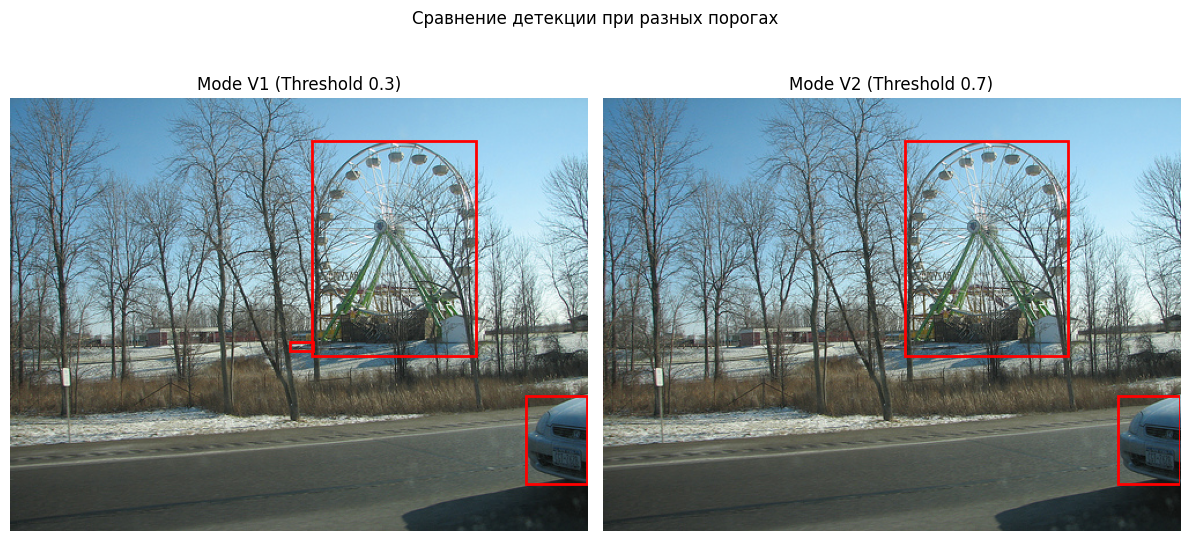

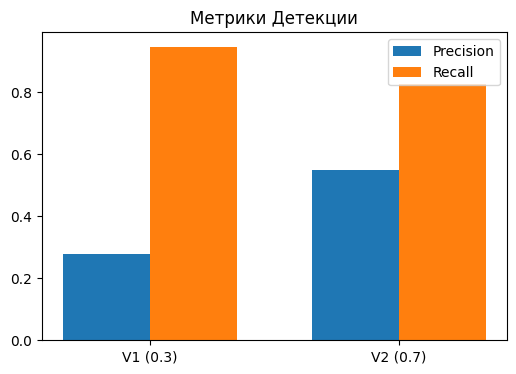

In [14]:
NUM_EVAL_IMAGES = 50 # Берем первые 50 картинок
iou_threshold = 0.5

# Режимы
thresholds = {"V1": 0.3, "V2": 0.7}
metrics_res = { "V1": {"tp":0, "fp":0, "fn":0, "ious":[]}, "V2": {"tp":0, "fp":0, "fn":0, "ious":[]} }

print(f"Выполняем инференс на {NUM_EVAL_IMAGES} изображениях...")
with torch.no_grad():
    for i in range(NUM_EVAL_IMAGES):
        img_pil, target = voc_val[i]
        gt_boxes = get_gt_boxes(target)

        # Подготовка картинки для модели
        img_tensor = detection_transforms(img_pil).unsqueeze(0).to(device)
        predictions = detection_model(img_tensor)[0]

        preds_boxes = predictions['boxes'].cpu()
        preds_scores = predictions['scores'].cpu()

        # Для каждого режима
        for mode, thresh in thresholds.items():
            valid_mask = preds_scores >= thresh
            filtered_boxes = preds_boxes[valid_mask]

            tp, fp, fn, matched_ious = compute_detection_metrics(filtered_boxes, gt_boxes, iou_threshold)
            metrics_res[mode]["tp"] += tp
            metrics_res[mode]["fp"] += fp
            metrics_res[mode]["fn"] += fn
            metrics_res[mode]["ious"].extend(matched_ious)

# Считаем итоговые метрики и сохраняем их в CSV
for mode, thresh in thresholds.items():
    tp, fp, fn, ious = metrics_res[mode]["tp"], metrics_res[mode]["fp"], metrics_res[mode]["fn"], metrics_res[mode]["ious"]

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    mean_iou = np.mean(ious) if len(ious) > 0 else 0.0

    print(f"Режим {mode} (thr={thresh}): Precision={precision:.3f}, Recall={recall:.3f}, MeanIoU={mean_iou:.3f}")

    results_log.append({
        "experiment_id": mode, "task": "detection", "dataset": "Pascal VOC", "seed": 42,
        "model_summary": "FasterRCNN_ResNet50_FPN", "optimizer": None, "lr": None, "epochs_trained": None,
        "best_val_accuracy": None, "test_accuracy": None,
        "precision": round(precision, 4), "recall": round(recall, 4), "mean_iou": round(mean_iou, 4),
        "notes": f"Score threshold {thresh}"
    })

sample_img_pil, sample_target = voc_val[10] # Картинка 10
sample_tensor = detection_transforms(sample_img_pil).unsqueeze(0).to(device)
with torch.no_grad():
    sample_preds = detection_model(sample_tensor)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Сравнение детекции при разных порогах")

for idx, (mode, thresh) in enumerate(thresholds.items()):
    ax = axes[idx]
    ax.imshow(sample_img_pil)
    ax.set_title(f"Mode {mode} (Threshold {thresh})")
    ax.axis('off')

    valid_mask = sample_preds['scores'] >= thresh
    boxes = sample_preds['boxes'][valid_mask].cpu().numpy()

    for box in boxes:
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

plt.tight_layout()
plt.savefig(os.path.join(figures, "detection_examples.png"))
plt.show()

precisions = [results_log[-2]['precision'], results_log[-1]['precision']]
recalls = [results_log[-2]['recall'], results_log[-1]['recall']]

x = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, precisions, width, label='Precision')
ax.bar(x + width/2, recalls, width, label='Recall')
ax.set_xticks(x); ax.set_xticklabels(['V1 (0.3)', 'V2 (0.7)'])
ax.legend(); ax.set_title("Метрики Детекции")
plt.savefig(os.path.join(figures, "detection_metrics.png"))
plt.show()

# Ячейка 7: Финал и сохранение таблицы результатов

In [15]:
# Сохраняем итоговую таблицу
df_results = pd.DataFrame(results_log)
df_results.to_csv(os.path.join(artifacts, "runs.csv"), index=False)

print("Файл runs.csv успешно сохранен!")
display(df_results)

Файл runs.csv успешно сохранен!


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple-cnn-base,Adam,0.0010,10.0,0.486,NaN,NaN,NaN,NaN,Best val acc: 0.4860
1,C2,classification,STL10,42,simple-cnn-aug,Adam,0.0010,10.0,0.507,NaN,NaN,NaN,NaN,Best val acc: 0.5070
2,C3,classification,STL10,42,resnet-head,Adam,0.0010,10.0,0.940,NaN,NaN,NaN,NaN,Best val acc: 0.9400
3,C4,classification,STL10,42,resnet-finetune,Adam,0.0001,10.0,0.957,0.9461,NaN,NaN,NaN,Best val acc: 0.9570
4,V1,detection,Pascal VOC,42,FasterRCNN_ResNet50_FPN,None,NaN,NaN,NaN,NaN,0.2784,0.9450,0.8041,Score threshold 0.3
5,V2,detection,Pascal VOC,42,FasterRCNN_ResNet50_FPN,None,NaN,NaN,NaN,NaN,0.5488,0.8257,0.8171,Score threshold 0.7
